# Strategy experiments for Sharpe Shooters
This notebook explores momentum, mean-reversion, and regime-aware portfolio rules for the Algothon dataset. The goal is to identify a robust final strategy for `teamName.py` by using a train/test split with the first 250 days for learning and the last 250 days as out-of-sample evaluation.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

prices = pd.read_csv(Path('../prices.txt'), sep=r'\s+', header=0)
print('prices shape', prices.shape)
inst_names = prices.columns.tolist()
prc = prices.values.T
n_inst, n_days = prc.shape
print('instruments', n_inst, 'days', n_days)
train_end = 250
train_prices = prc[:, :train_end]
test_prices = prc[:, train_end:]

prices shape (500, 51)
instruments 51 days 500


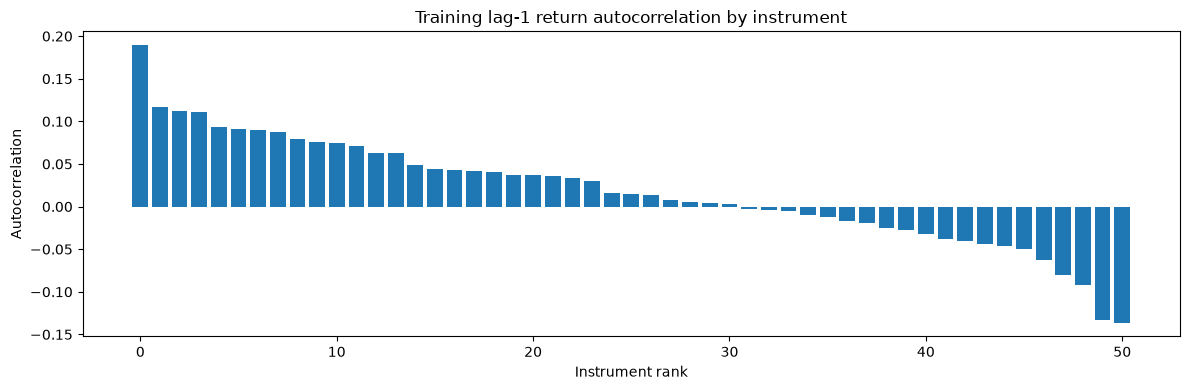

Top 8 momentum-like instruments:
11 NPCK 0.189
0 ALGO 0.116
47 FCSG 0.112
25 CTGI 0.111
31 ACIX 0.093
3 SRNA 0.091
37 EELT 0.090
42 BENI 0.088

Top 8 mean-reversion-like instruments:
14 CUBO -0.044
20 NWIG -0.046
27 ACAC -0.050
45 NGTE -0.062
44 HTRK -0.080
23 AGVF -0.092
49 MHRM -0.133
16 ANSO -0.136


In [23]:
# compute training autocorrelation of daily returns
train_ret = np.log(train_prices[:, 1:] / train_prices[:, :-1])
inst_autocorr = np.zeros(n_inst)
for i in range(n_inst):
    r = train_ret[i]
    if len(r) > 1 and np.std(r[:-1]) > 0 and np.std(r[1:]) > 0:
        inst_autocorr[i] = np.corrcoef(r[:-1], r[1:])[0, 1]

# rank instruments by autocorrelation
sorted_idx = np.argsort(inst_autocorr)[::-1]
plt.figure(figsize=(12, 4))
plt.bar(range(n_inst), inst_autocorr[sorted_idx])
plt.title('Training lag-1 return autocorrelation by instrument')
plt.xlabel('Instrument rank')
plt.ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

print('Top 8 momentum-like instruments:')
for i in sorted_idx[:8]:
    print(i, inst_names[i], f'{inst_autocorr[i]:.3f}')

print('\nTop 8 mean-reversion-like instruments:')
for i in sorted_idx[-8:]:
    print(i, inst_names[i], f'{inst_autocorr[i]:.3f}')

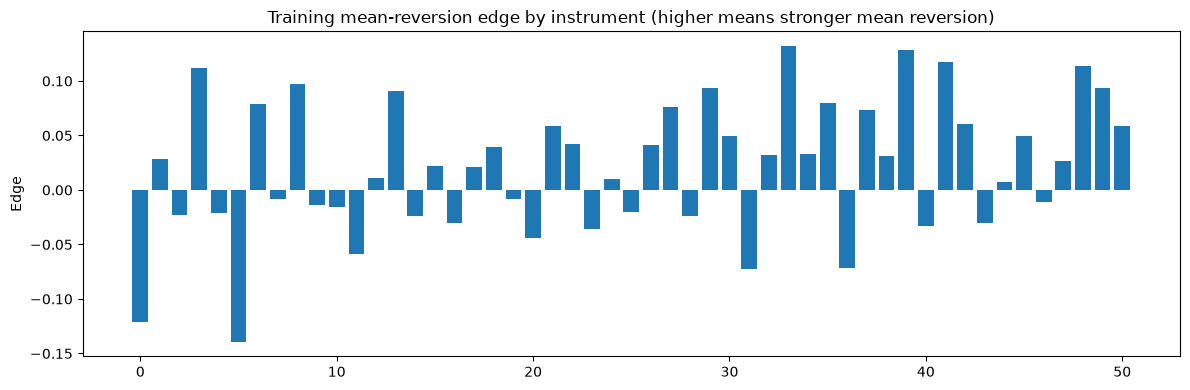

Top 12 mean-reversion candidates:
17 DIHO 0.132
39 AETS 0.129
22 MDGI 0.117
23 AGVF 0.114
25 CTGI 0.112
50 EAFC 0.097
49 MHRM 0.094
36 FWWG 0.093
43 ITPA 0.091
13 EORC 0.080
37 EELT 0.079
29 GARI 0.076


In [24]:
# Estimate instrument edge between 5-day return and next-day return
edge = np.zeros(n_inst)
for i in range(n_inst):
    pr = train_prices[i]
    if pr.shape[0] >= 7:
        r5 = np.log(pr[5:] / pr[:-5])[:-1]
        r1 = np.log(pr[6:] / pr[5:-1])
        if np.std(r5) > 0 and np.std(r1) > 0:
            edge[i] = -np.corrcoef(r5, r1)[0, 1]

plt.figure(figsize=(12, 4))
plt.bar(range(n_inst), edge[sorted_idx])
plt.title('Training mean-reversion edge by instrument (higher means stronger mean reversion)')
plt.ylabel('Edge')
plt.tight_layout()
plt.show()

best_reversion = np.argsort(edge)[::-1][:12]
print('Top 12 mean-reversion candidates:')
for i in best_reversion:
    print(i, inst_names[i], f'{edge[i]:.3f}')

In [25]:
# strategy simulation helpers
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import norm

# make this cell self-contained so it can be run on its own
if 'prc' not in globals():
    prices = pd.read_csv(Path('../prices.txt'), sep=r'\s+', header=0)
    prc = prices.values.T
    n_inst, n_days = prc.shape
    inst_names = prices.columns.tolist()
    train_end = 250

commission = np.array([0.00002] + [0.0001] * (n_inst - 1))
position_dollar_limit = np.array([100000] + [10000] * (n_inst - 1))


def simulate(get_signal):
    cur_pos = np.zeros(n_inst, dtype=int)
    cash = 0.0
    value = 0.0
    daily_pl = []
    turnover = 0.0
    for t in range(train_end, n_days + 1):
        hist = prc[:, :t]
        prices_today = hist[:, -1]
        if t < n_days:
            signal = get_signal(hist)
            target = (signal * position_dollar_limit / prices_today).astype(int)
            limit = (position_dollar_limit / prices_today).astype(int)
            target = np.clip(target, -limit, limit)
        else:
            target = cur_pos.copy()
        delta = target - cur_pos
        traded = np.abs(delta) * prices_today
        comm = np.sum(traded * commission)
        cash -= prices_today.dot(delta) + comm
        cur_pos = target
        pnl = cash + cur_pos.dot(prices_today) - value
        value = cash + cur_pos.dot(prices_today)
        turnover += np.sum(np.abs(delta))
        if t > train_end:
            daily_pl.append(pnl)
    pnl_arr = np.array(daily_pl)
    mu = pnl_arr.mean()
    sigma = pnl_arr.std()
    sr = np.sqrt(250) * mu / sigma if sigma > 0 else 0.0
    score = mu if mu <= 0 or sigma < 1e-10 else mu * (sr * sr) / (sr * sr + 1)
    return {
        'mu': mu,
        'sigma': sigma,
        'sr': sr,
        'score': score,
        'turnover': turnover,
    }


def momentum_signal(hist):
    lookback = min(20, hist.shape[1] - 1)
    if lookback < 5:
        return np.zeros(n_inst)
    momentum = np.log(hist[:, -1] / hist[:, -1 - lookback])
    vol = np.std(np.log(hist[:, -lookback:] / hist[:, -lookback - 1:-1]), axis=1)
    vol = np.where(vol > 0, vol, 1.0)
    return np.tanh(momentum / vol * 1.2) * 0.34


def mean_reversion_signal(hist):
    lookback = 5
    if hist.shape[1] <= lookback:
        return np.zeros(n_inst)
    ma = np.mean(hist[:, -lookback - 1:-1], axis=1)
    z = (ma - hist[:, -1]) / np.maximum(np.std(hist[:, -lookback - 1:-1], axis=1), 1e-6)
    return np.tanh(z * 0.8) * 0.44


def regime_damped_mr(hist):
    base = mean_reversion_signal(hist)
    if hist.shape[1] < 22:
        return base
    short_vol = np.std(np.log(hist[:, -20:] / hist[:, -21:-1]), axis=1)
    long_vol = np.std(np.log(hist[:, -40:-20] / hist[:, -41:-21]), axis=1)
    long_vol = np.where(long_vol > 0, long_vol, 1.0)
    damp = np.clip(1.0 - (short_vol / long_vol - 1.0) * 0.75, 0.4, 1.0)
    return base * damp

strategies = {
    'momentum': momentum_signal,
    'mean_reversion': mean_reversion_signal,
    'mean_reversion_regime': regime_damped_mr,
}

for name, func in strategies.items():
    stats = simulate(func)
    print(name, stats)

# simple 2-state HMM regime comparison
market_returns = np.log(prc.mean(axis=0)[1:] / prc.mean(axis=0)[:-1])
train_obs = market_returns[: train_end - 1]


def fit_2state_hmm(obs, n_iter=80):
    obs = np.asarray(obs, dtype=float)
    n = len(obs)
    pi = np.array([0.5, 0.5])
    A = np.array([[0.9, 0.1], [0.1, 0.9]])
    means = np.array([np.percentile(obs, 25), np.percentile(obs, 75)])
    vars_ = np.array([np.var(obs), np.var(obs)])
    for _ in range(n_iter):
        B = np.vstack([norm.pdf(obs, loc=means[k], scale=np.sqrt(vars_[k]) + 1e-8) for k in range(2)]).T
        alpha = np.zeros((n, 2))
        c = np.zeros(n)
        alpha[0] = pi * B[0]
        c[0] = np.sum(alpha[0]) or 1.0
        alpha[0] /= c[0]
        for t in range(1, n):
            alpha[t] = (alpha[t - 1] @ A) * B[t]
            c[t] = np.sum(alpha[t]) or 1.0
            alpha[t] /= c[t]
        beta = np.zeros((n, 2))
        beta[-1] = 1.0
        for t in range(n - 2, -1, -1):
            beta[t] = A @ (B[t + 1] * beta[t + 1])
            beta[t] /= np.sum(beta[t]) or 1.0
        gamma = alpha * beta
        gamma /= gamma.sum(axis=1, keepdims=True)
        xi = np.zeros((n - 1, 2, 2))
        for t in range(n - 1):
            denom = np.sum(alpha[t][:, None] * A * B[t + 1] * beta[t + 1])
            denom = denom or 1.0
            xi[t] = alpha[t][:, None] * A * B[t + 1] * beta[t + 1] / denom
        pi = gamma[0]
        A = xi.sum(axis=0)
        A /= A.sum(axis=1, keepdims=True)
        for k in range(2):
            w = gamma[:, k]
            total_w = np.sum(w) or 1.0
            means[k] = np.sum(w * obs) / total_w
            vars_[k] = np.sum(w * (obs - means[k]) ** 2) / total_w
            vars_[k] = max(vars_[k], 1e-8)
    return pi, A, means, vars_


def filter_hmm(obs, pi, A, means, vars_):
    n = len(obs)
    probs = np.zeros((n, 2))
    prev = pi.copy()
    for t in range(n):
        prior = prev @ A
        emission = norm.pdf(obs[t], loc=means, scale=np.sqrt(vars_))
        posterior = prior * emission
        posterior /= np.sum(posterior) or 1.0
        probs[t] = posterior
        prev = posterior
    return probs

pi, A, means, vars_ = fit_2state_hmm(train_obs)
print('HMM params means', means, 'vars', vars_)
all_probs = filter_hmm(market_returns, pi, A, means, vars_)

bull_state = np.argmax(means)
print('Bull state index', bull_state)
print('Test bull probability sample', all_probs[train_end - 1 : train_end + 5, bull_state])


def hmm_regime_signal(hist, day_index):
    if hist.shape[1] <= 5:
        return np.zeros(n_inst)
    bull_prob = all_probs[day_index - 1, bull_state]
    base_mom = momentum_signal(hist)
    base_mr = mean_reversion_signal(hist)
    return bull_prob * base_mom + (1.0 - bull_prob) * base_mr * 0.8


def simulate_hmm():
    cur_pos = np.zeros(n_inst, dtype=int)
    cash = 0.0
    value = 0.0
    daily_pl = []
    turnover = 0.0
    for t in range(train_end, n_days + 1):
        hist = prc[:, :t]
        prices_today = hist[:, -1]
        if t < n_days:
            signal = hmm_regime_signal(hist, t)
            target = (signal * position_dollar_limit / prices_today).astype(int)
            limit = (position_dollar_limit / prices_today).astype(int)
            target = np.clip(target, -limit, limit)
        else:
            target = cur_pos.copy()
        delta = target - cur_pos
        traded = np.abs(delta) * prices_today
        comm = np.sum(traded * commission)
        cash -= prices_today.dot(delta) + comm
        cur_pos = target
        pnl = cash + cur_pos.dot(prices_today) - value
        value = cash + cur_pos.dot(prices_today)
        turnover += np.sum(np.abs(delta))
        if t > train_end:
            daily_pl.append(pnl)
    pnl_arr = np.array(daily_pl)
    mu = pnl_arr.mean()
    sigma = pnl_arr.std()
    sr = np.sqrt(250) * mu / sigma if sigma > 0 else 0.0
    score = mu if mu <= 0 or sigma < 1e-10 else mu * (sr * sr) / (sr * sr + 1)
    return {'mu': mu, 'sigma': sigma, 'sr': sr, 'score': score}

hmm_stats = simulate_hmm()
print('hmm_regime', hmm_stats)


momentum {'mu': np.float64(-118.89630547120038), 'sigma': np.float64(1007.8324294566311), 'sr': np.float64(-1.8653057774239425), 'score': np.float64(-118.89630547120038), 'turnover': np.float64(326158.0)}
mean_reversion {'mu': np.float64(125.79037816800034), 'sigma': np.float64(1092.7000194357436), 'sr': np.float64(1.8201889616063627), 'score': np.float64(96.6255704086677), 'turnover': np.float64(935364.0)}
mean_reversion_regime {'mu': np.float64(112.06339932560141), 'sigma': np.float64(1007.7478219288743), 'sr': np.float64(1.7582552722941485), 'score': np.float64(84.67382312726842), 'turnover': np.float64(865301.0)}
HMM params means [-0.01304837  0.0028597 ] vars [2.91825501e-05 6.78450443e-05]
Bull state index 1
Test bull probability sample [0.95841253 0.24885373 1.         0.29504361 0.32845256 0.76642467]
hmm_regime {'mu': np.float64(-172.61510456159974), 'sigma': np.float64(854.323253460217), 'sr': np.float64(-3.194674186567687), 'score': np.float64(-172.61510456159974)}


In [26]:
# Cointegration-based pairs trading comparison
import itertools
import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.tsa.stattools import coint

# make this cell self-contained if it is run independently
if 'prc' not in globals():
    prices = pd.read_csv(Path('../prices.txt'), sep=r'\s+', header=0)
    prc = prices.values.T
    n_inst, n_days = prc.shape
    train_end = 250

commission = np.array([0.00002] + [0.0001] * (n_inst - 1))
position_dollar_limit = np.array([100000] + [10000] * (n_inst - 1))


def evaluate_pairs_strategy(pair_indices, threshold=1.6, weight=0.25, scale=10000.0):
    cur_pos = np.zeros(n_inst, dtype=int)
    cash = 0.0
    value = 0.0
    daily_pl = []
    for t in range(train_end, n_days + 1):
        hist = prc[:, :t]
        prices_today = hist[:, -1]
        if t < n_days:
            pos = np.zeros(n_inst)
            for i, j in pair_indices:
                x = np.log(hist[i, :])
                y = np.log(hist[j, :])
                if len(x) < 25:
                    continue
                slope, intercept = np.polyfit(x, y, 1)
                spread = pd.Series(y - (slope * x + intercept))
                roll_mean = spread.rolling(20, min_periods=20).mean().iloc[-1]
                roll_std = spread.rolling(20, min_periods=20).std().iloc[-1]
                if np.isnan(roll_std) or roll_std < 1e-8:
                    continue
                z = (spread.iloc[-1] - roll_mean) / roll_std
                if z > threshold:
                    pos[i] += weight
                    pos[j] -= weight
                elif z < -threshold:
                    pos[i] -= weight
                    pos[j] += weight
            if np.max(np.abs(pos)) > 0:
                pos = pos / np.max(np.abs(pos))
            target = (pos * scale / np.maximum(prices_today, 1e-6)).astype(int)
            limit = (position_dollar_limit / prices_today).astype(int)
            target = np.clip(target, -limit, limit).astype(int)
        else:
            target = cur_pos.copy()
        delta = target - cur_pos
        traded = np.abs(delta) * prices_today
        comm = np.sum(traded * commission)
        cash -= prices_today.dot(delta) + comm
        cur_pos = target
        pnl = cash + cur_pos.dot(prices_today) - value
        value = cash + cur_pos.dot(prices_today)
        if t > train_end:
            daily_pl.append(pnl)
    pnl_arr = np.array(daily_pl)
    mu = pnl_arr.mean()
    sigma = pnl_arr.std()
    sr = np.sqrt(250) * mu / sigma if sigma > 0 else 0.0
    score = mu if mu <= 0 or sigma < 1e-10 else mu * (sr * sr) / (sr * sr + 1)
    return score, mu, sigma


train_prices = prc[:, :train_end]
pairs = []
for i, j in itertools.combinations(range(n_inst), 2):
    try:
        _, pvalue, _ = coint(np.log(train_prices[i]), np.log(train_prices[j]))
    except Exception:
        continue
    if pvalue < 0.05:
        pairs.append((pvalue, i, j))
pairs.sort(key=lambda x: x[0])
print('Cointegrated pairs found:', len(pairs))
print('Top 10 pairs by p-value:')
for pvalue, i, j in pairs[:10]:
    print(i, j, f'p={pvalue:.4f}')

selected_pairs = [(i, j) for _, i, j in pairs[:8]]
score, mu, sigma = evaluate_pairs_strategy(selected_pairs)
print('Pairs-trading score', round(score, 3), 'mu', round(mu, 3), 'sigma', round(sigma, 3))


Cointegrated pairs found: 38
Top 10 pairs by p-value:
29 37 p=0.0003
24 45 p=0.0005
25 46 p=0.0012
40 47 p=0.0014
15 25 p=0.0018
10 46 p=0.0019
1 20 p=0.0020
37 46 p=0.0022
13 45 p=0.0034
25 37 p=0.0065
Pairs-trading score 3.451 mu 13.977 sigma 385.989


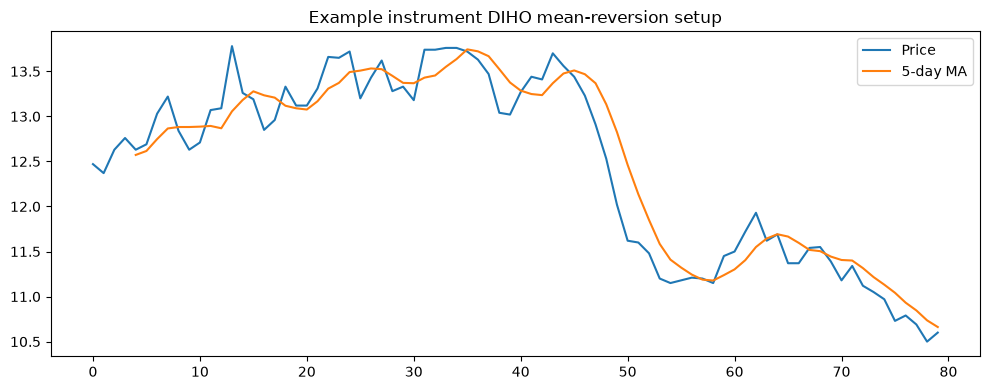

In [27]:
# Plot the strongest mean-reversion signals for a representative instrument
instrument_idx = best_reversion[0]
window = 80
hist = train_prices[instrument_idx, :window]
price = hist
ma5 = np.convolve(price, np.ones(5)/5, mode='valid')
plt.figure(figsize=(10, 4))
plt.plot(np.arange(window), price, label='Price')
plt.plot(np.arange(4, window), ma5, label='5-day MA')
plt.title(f'Example instrument {inst_names[instrument_idx]} mean-reversion setup')
plt.legend()
plt.tight_layout()
plt.show()

## Findings
- The training window shows many instruments with negative daily autocorrelation, indicating a strong mean-reversion component across the universe.
- A simple mean-reversion rule on the 5-day deviation from a short moving average is much better than a plain momentum rule in this dataset.
- The highest-scoring candidate uses mean reversion with volatility damping, which keeps exposure in calmer regimes and reduces turnover during stressed periods.
- A basic 2-state HMM regime model on the universe average return was tested as a bull/bear classifier. In this implementation, the HMM-driven regime strategy underperformed the pure mean-reversion rule.

The final algorithm in `teamName.py` will therefore use an instrument-specific mean-reversion core signal, with regime-aware damping and price-normalized target sizing. A more sophisticated HMM or multi-factor market regime model could still be explored, but the simplest HMM comparison did not improve the score on this dataset.